In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Define Data

In [2]:
# Define data
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state=3000
)

# Gaussian NB

In [3]:
from sklearn.naive_bayes import GaussianNB

In [4]:
clf = GaussianNB()
clf.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [5]:
y_pred = clf.predict(X_test)

In [6]:
accuracy = accuracy_score(y_pred, y_test)
print(accuracy)

0.8888888888888888


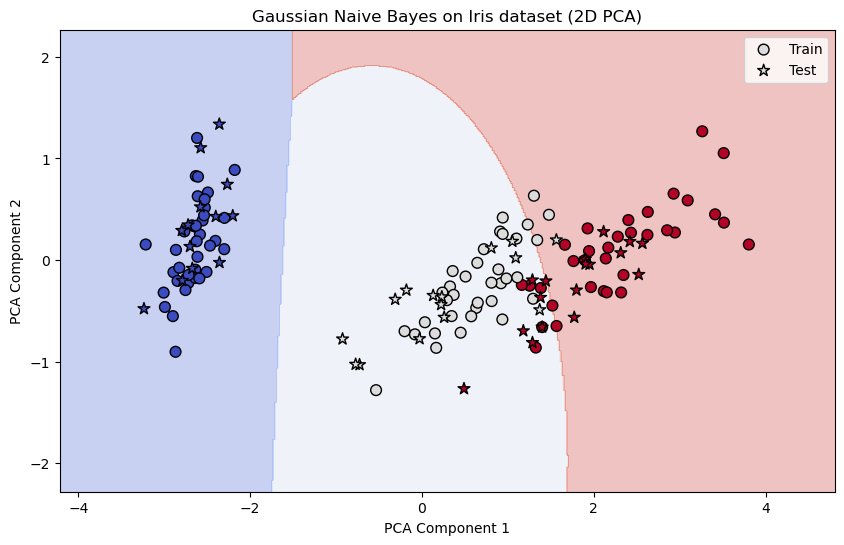

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

# -------------------------------
# 1. Load data and train Gaussian NB
# -------------------------------
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=3000
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

# -------------------------------
# 2. Reduce to 2D with PCA for plotting
# -------------------------------
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

# Train GaussianNB on the 2D projection for plotting
gnb_2D = GaussianNB()
gnb_2D.fit(X_train_2D, y_train)

# -------------------------------
# 3. Create meshgrid for decision regions
# -------------------------------
x_min, x_max = X_train_2D[:,0].min() - 1, X_train_2D[:,0].max() + 1
y_min, y_max = X_train_2D[:,1].min() - 1, X_train_2D[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict class for each point in the grid
Z = gnb_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# -------------------------------
# 4. Plot
# -------------------------------
plt.figure(figsize=(10,6))

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Training points
plt.scatter(X_train_2D[:,0], X_train_2D[:,1], c=y_train, s=60,
            edgecolors='k', cmap=plt.cm.coolwarm, label='Train')

# Test points
plt.scatter(X_test_2D[:,0], X_test_2D[:,1], c=y_test, s=80, marker='*',
            edgecolors='k', cmap=plt.cm.coolwarm, label='Test')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian Naive Bayes on Iris dataset (2D PCA)")
plt.legend()
plt.show()


# Support Vector Machines(SVM)

In [8]:
from sklearn import svm
clf = svm.SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [9]:
accuracy = accuracy_score(y_pred, y_test)
print(accuracy)

0.9111111111111111


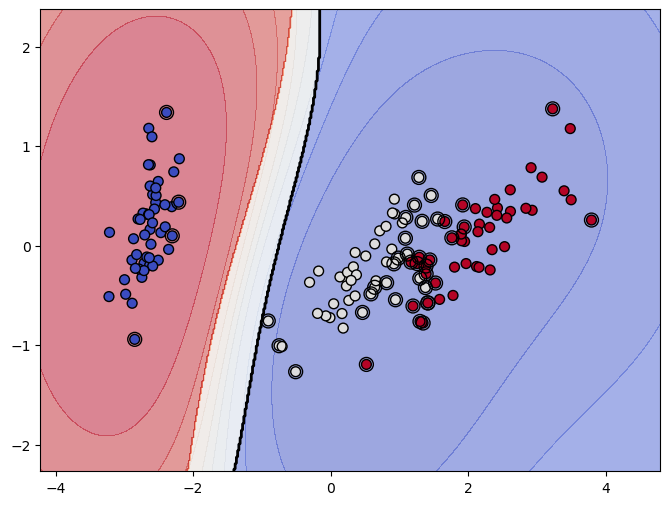

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduce X to 2D
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X)

# Train a new SVM on the reduced 2D data (optional)
from sklearn.svm import SVC
clf_2D = svm.SVC(kernel='rbf', C=1)
clf_2D.fit(X_2D, y)

# Create a meshgrid for 2D
xx, yy = np.meshgrid(np.linspace(X_2D[:,0].min()-1, X_2D[:,0].max()+1, 500),
                     np.linspace(X_2D[:,1].min()-1, X_2D[:,1].max()+1, 500))

# Compute decision function
Z = clf_2D.decision_function(np.c_[xx.ravel(), yy.ravel()])

# For multiclass SVM, pick the first class's scores (or use argmax)
if Z.ndim > 1:
    Z = Z[:, 0]  # take decision scores for class 0
    # Or use predicted class labels
    # Z = clf_2D.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)


plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 50), cmap=plt.cm.coolwarm, alpha=0.5)
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

plt.scatter(X_2D[:,0], X_2D[:,1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')
plt.scatter(clf_2D.support_vectors_[:,0], clf_2D.support_vectors_[:,1], s=100, facecolors='none', edgecolors='k')
plt.show()


# Decision Trees

In [11]:
from sklearn import tree

In [16]:
clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print(accuracy)

0.8666666666666667
